In [ ]:
import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer
from omegaconf import OmegaConf
import pandas as pd


In [117]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]

SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=128 , calculate_second_order=True)

unscaled = SA.generate_samples()
rescaled = SA.rescale_samples()
samples = SA.apply_dependent_parameters(dependent_parameters)
samples

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,181919.596742
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.519430,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3579,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000003,3.605056,20.287596,2.398945,198225.752093
3580,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000005,33.521137,20.287596,2.398945,198225.752093
3581,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000005,3.605056,16.576962,2.398945,198225.752093
3582,357.141786,218225.752093,1.535442,0.576896,0.656774,2.228205,0.228680,0.268379,4,0.000005,3.605056,20.287596,1.557878,198225.752093


In [3]:
dejvis = samples[0:15000]
camila = samples[15000:21836]
nathaly = samples[21836:]
camila

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des


In [97]:
import pandas as pd
import glob
import os
import re
import sys

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters

# Locate all pickle files in the folder
all_files = glob.glob('../sampling_test/*.pkl')
file_paths = [
    f for f in all_files
    if 'camila' not in os.path.basename(f).lower() and 'nathaly' not in os.path.basename(f).lower() and 'results' in os.path.basename(f).lower() 
]

# Helper function to extract number from filename
def extract_number(filename):
    match = re.search(r'(\d+)', os.path.basename(filename))
    return int(match.group(1)) if match else float('inf')  # Files with no number will go last

# Sort the file paths based on the extracted number
file_paths_sorted = sorted(file_paths, key=extract_number)

# Read each pickle file into a DataFrame and collect them
df_list = [pd.read_pickle(path) for path in file_paths_sorted]

# Concatenate all DataFrames vertically into one
combined_df = pd.concat(df_list, ignore_index=True)

# Print the overall shape
print(f"Combined DataFrame shape: {combined_df.shape}")

# Drop NaNs
data = combined_df.dropna()
print(f"Data shape after dropping NaN: {data.shape}")


Combined DataFrame shape: (15000, 48)
Data shape after dropping NaN: (14982, 48)


In [51]:
d1 = pd.read_pickle('../data/raw/correct_sobol_sampling/results/results_nathaly_sobol_samples_n1000_from_leftover_n3336_on_22.06.2025.pkl')
d2 = pd.read_pickle('../data/raw/correct_sobol_sampling/results/results_nathaly_sobol_samples_n1500_on_21.06.2025.pkl')
d3 = pd.read_pickle('../data/raw/correct_sobol_sampling/results/results_nathaly_sobol_samples_n2000_from_leftover_n5336_on_21.06.2025.pkl')
d4 = pd.read_pickle('../sampling_test/results_sobol_nathaly1000.pkl')
d5 = pd.read_pickle('../sampling_test/results_sobol_nathaly_rest.pkl')
df_nathaly = pd.concat([d1, d2, d3, d4, d5], ignore_index=True)

df_nathaly.to_pickle('../sampling_test/nathaly6836.pkl')

In [52]:
d6 = pd.read_pickle('../data/raw/sobol_sampling_final_camila_compl.pkl')
d7 = pd.read_pickle('../sampling_test/results_sobol_camila5000.pkl')
d8 = pd.read_pickle('../sampling_test/results_sobol_camila6000.pkl')
d9 = pd.read_pickle('../sampling_test/results_sobol_camila_last836.pkl')
df_camila = pd.concat([d6, d7, d8, d9], ignore_index=True)
df_camila.to_pickle('../sampling_test/camila6836.pkl')

In [ ]:
all = pd.concat([combined_df, df_camila, df_nathaly], ignore_index=True)
all.to_pickle('../sampling_test/all_samples.pkl')
all

In [118]:
all = pd.read_pickle('../sampling_test/validated_final_df.pkl')

all

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.729581,0.720127,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933,valid
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.714529,0.707308,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718,valid
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.674925,0.678619,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506,valid
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.716600,0.706744,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362,valid
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.729362,0.719902,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740,valid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28667,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000005,...,0.625377,0.611309,0.597290,0.583306,0.569347,0.555400,0.541456,0.527501,0.513527,valid
28668,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,...,0.623167,0.611584,0.600051,0.588553,0.577079,0.565618,0.554158,0.542689,0.531200,valid
28669,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,...,0.678033,0.666486,0.654984,0.643514,0.632065,0.620625,0.609184,0.597730,0.586254,valid
28670,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,...,0.674628,0.664588,0.654633,0.644750,0.634929,0.625162,0.615438,0.605748,0.596083,valid


In [119]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
target_cols = [f"Ucell_{i}" for i in range(30)]
# Split features and targets
X = all.dropna()[parameter_ranges]
y = all.dropna()[target_cols]

# Wrap XGBRegressor to handle multi-output regression
model = MultiOutputRegressor(XGBRegressor())
model.fit(X, y)



,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None


In [120]:
narows = all[all['Ucell_0'].isna()][parameter_ranges]
na_pred = model.predict(narows.to_numpy())

In [121]:
na_pred

array([[ 1.02778172e+00,  9.81495142e-01,  7.62582123e-01,
         9.98042881e-01,  9.82553720e-01,  9.27009940e-01,
         8.06928396e-01,  8.08325231e-01,  5.36401570e-01,
         7.73691297e-01,  6.80978477e-01,  7.47518122e-01,
         8.79587293e-01,  7.91958988e-01,  5.56091368e-01,
         6.92171335e-01,  1.70461059e-01,  4.74189609e-01,
         5.43428719e-01,  5.03584385e-01,  3.47117424e-01,
         8.30415562e-02,  4.43241328e-01,  1.99486956e-01,
         1.64107218e-01, -1.88924283e-01,  2.36097142e-01,
         3.52770180e-01,  3.13713253e-01,  1.85418755e-01],
       [ 8.34205389e-01,  8.79416645e-01,  7.71169841e-01,
         8.22727680e-01,  9.02087450e-01,  8.03271115e-01,
         8.11443210e-01,  6.33930802e-01,  7.21528828e-01,
         5.22025466e-01,  6.38445139e-01,  6.36610270e-01,
         5.66811860e-01,  5.24697125e-01,  5.61928332e-01,
         4.44612205e-01,  5.02980590e-01,  6.74273431e-01,
         6.68797135e-01,  4.12180901e-01,  7.80146837e-

In [123]:
# Create a DataFrame for the predictions with the correct index and column names
pred_df = pd.DataFrame(na_pred, columns=target_cols, index=narows.index)

# Assign the predicted values back into the original `all` DataFrame
all.loc[narows.index, target_cols] = pred_df
all["Ucell"] = all[target_cols].apply(lambda row: row.tolist(), axis=1)

In [124]:
target_cols = [f"ifc_{i}" for i in range(30)]
# Split features and targets
X = all.dropna()[parameter_ranges]
y = all.dropna()[target_cols]

# Wrap XGBRegressor to handle multi-output regression
model = MultiOutputRegressor(XGBRegressor())
model.fit(X, y)

narows = all[all['ifc_0'].isna()][parameter_ranges]
na_pred = model.predict(narows.to_numpy())

# Create a DataFrame for the predictions with the correct index and column names
pred_df = pd.DataFrame(na_pred, columns=target_cols, index=narows.index)

# Assign the predicted values back into the original `all` DataFrame
all.loc[narows.index, target_cols] = pred_df
all["ifc"] = all[target_cols].apply(lambda row: row.tolist(), axis=1)

In [125]:
for prefix in ("Ucell", "ifc"):
    cols = [f"{prefix}_{i}" for i in range(31)]
    # build the list-column
    all[prefix] = all[cols].values.tolist()
    # drop the old scalars
    all.drop(columns=cols, inplace=True)


In [131]:
data = all
data['Ucell'] = data['Ucell'].apply(list)
data['ifc'] = data['ifc'].apply(list)

/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


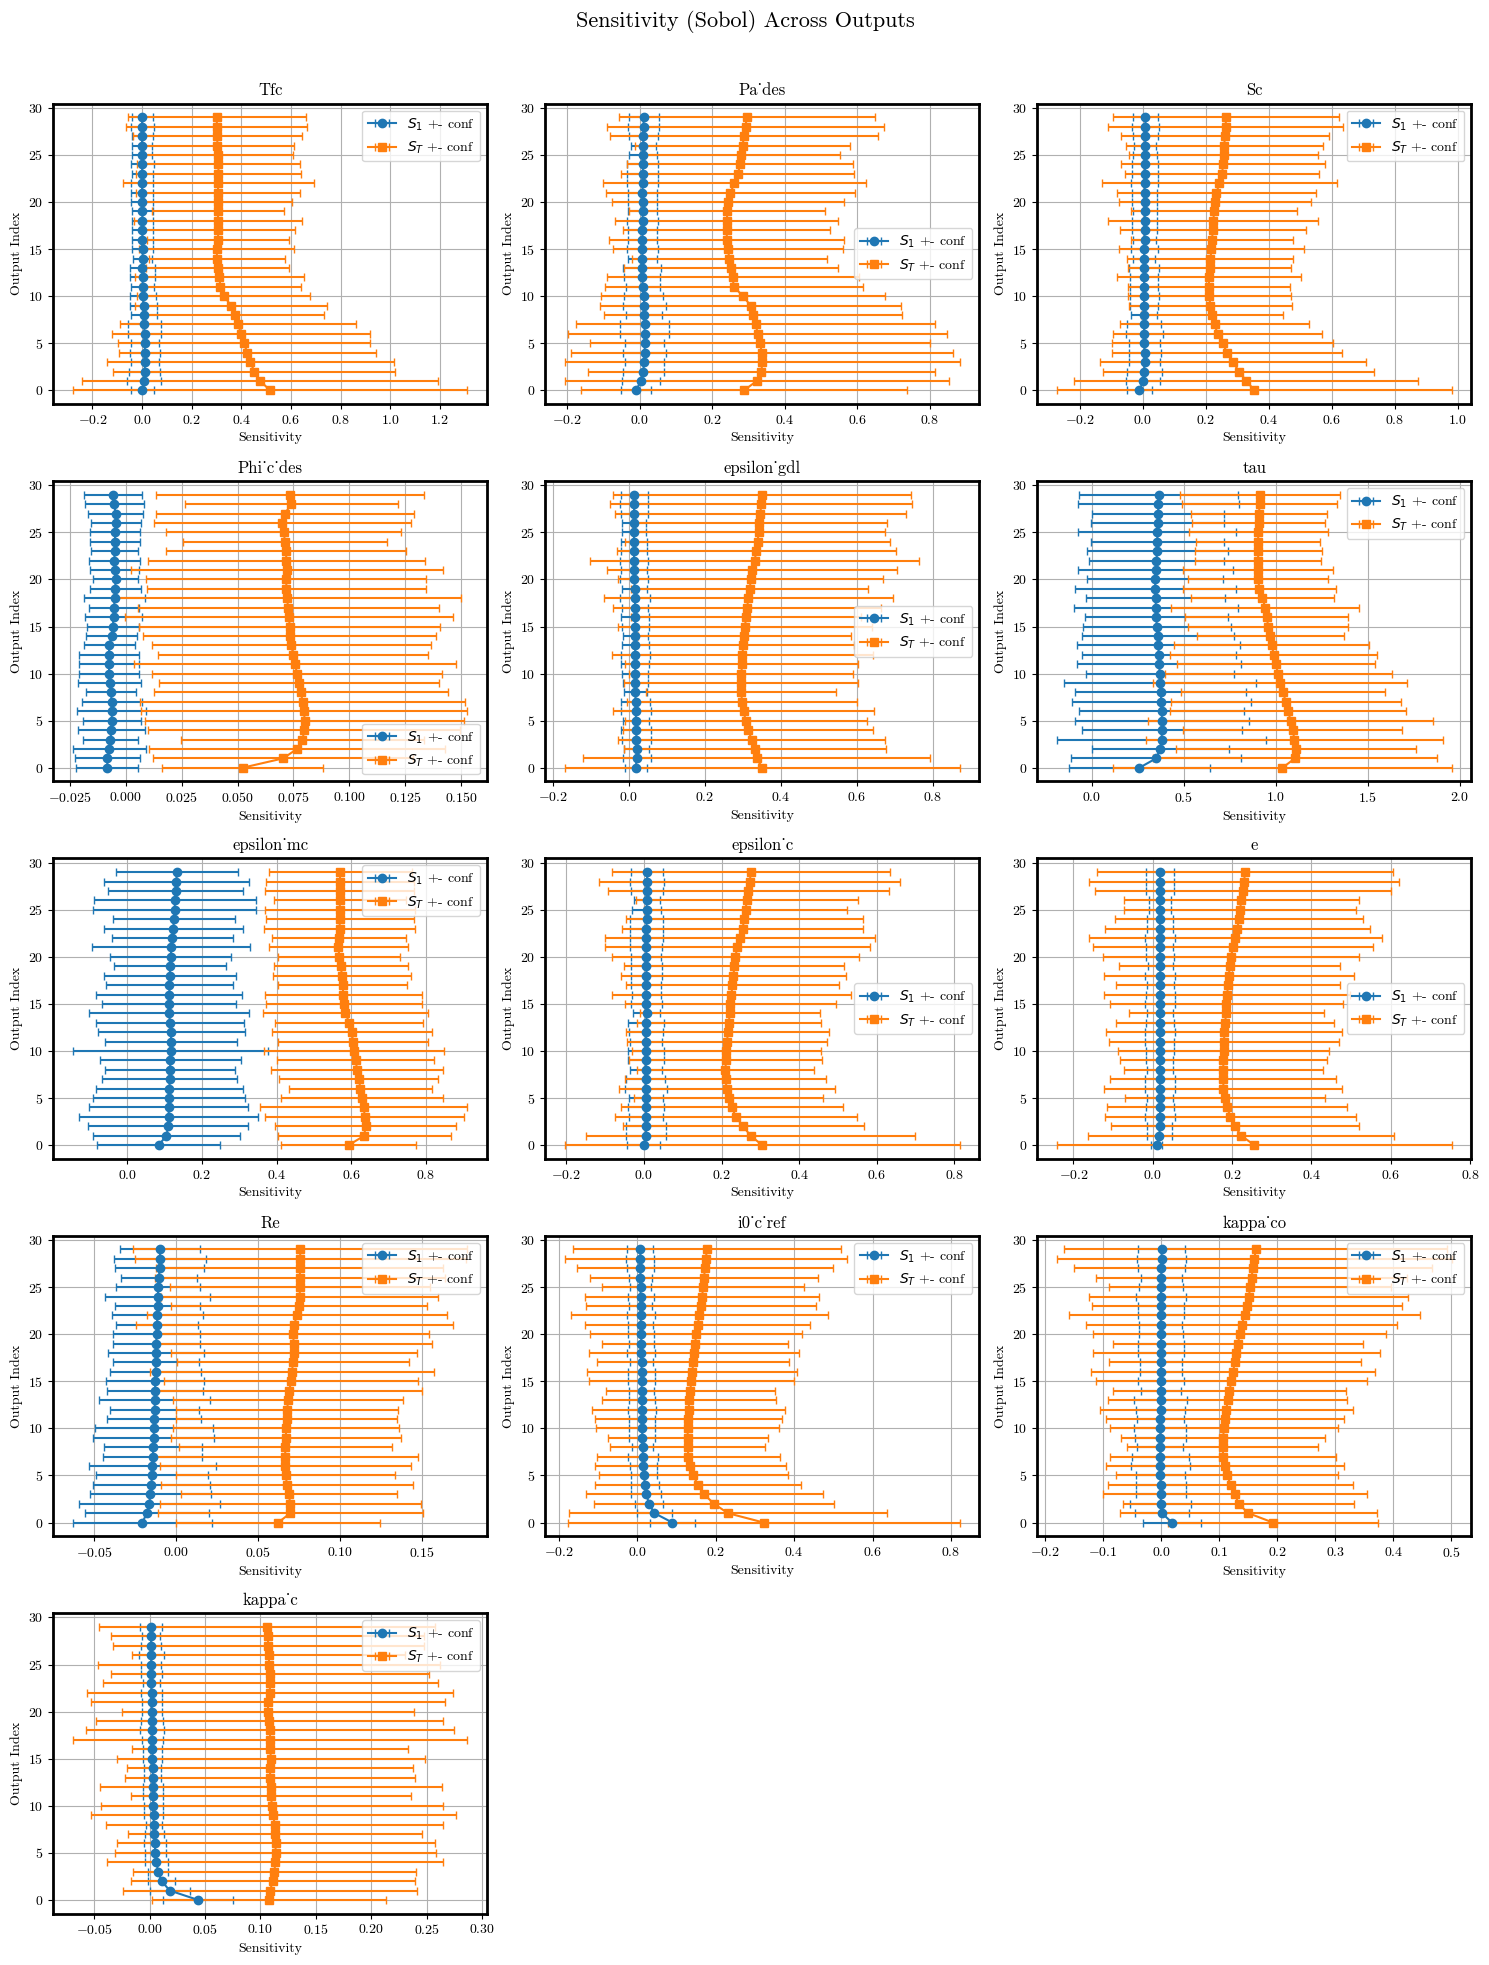

In [133]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=1024 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(data[cols][:len(samples)], by_regions=None, aggregation_method=None)
SA.plot_grid(results, same_axis=False)

/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


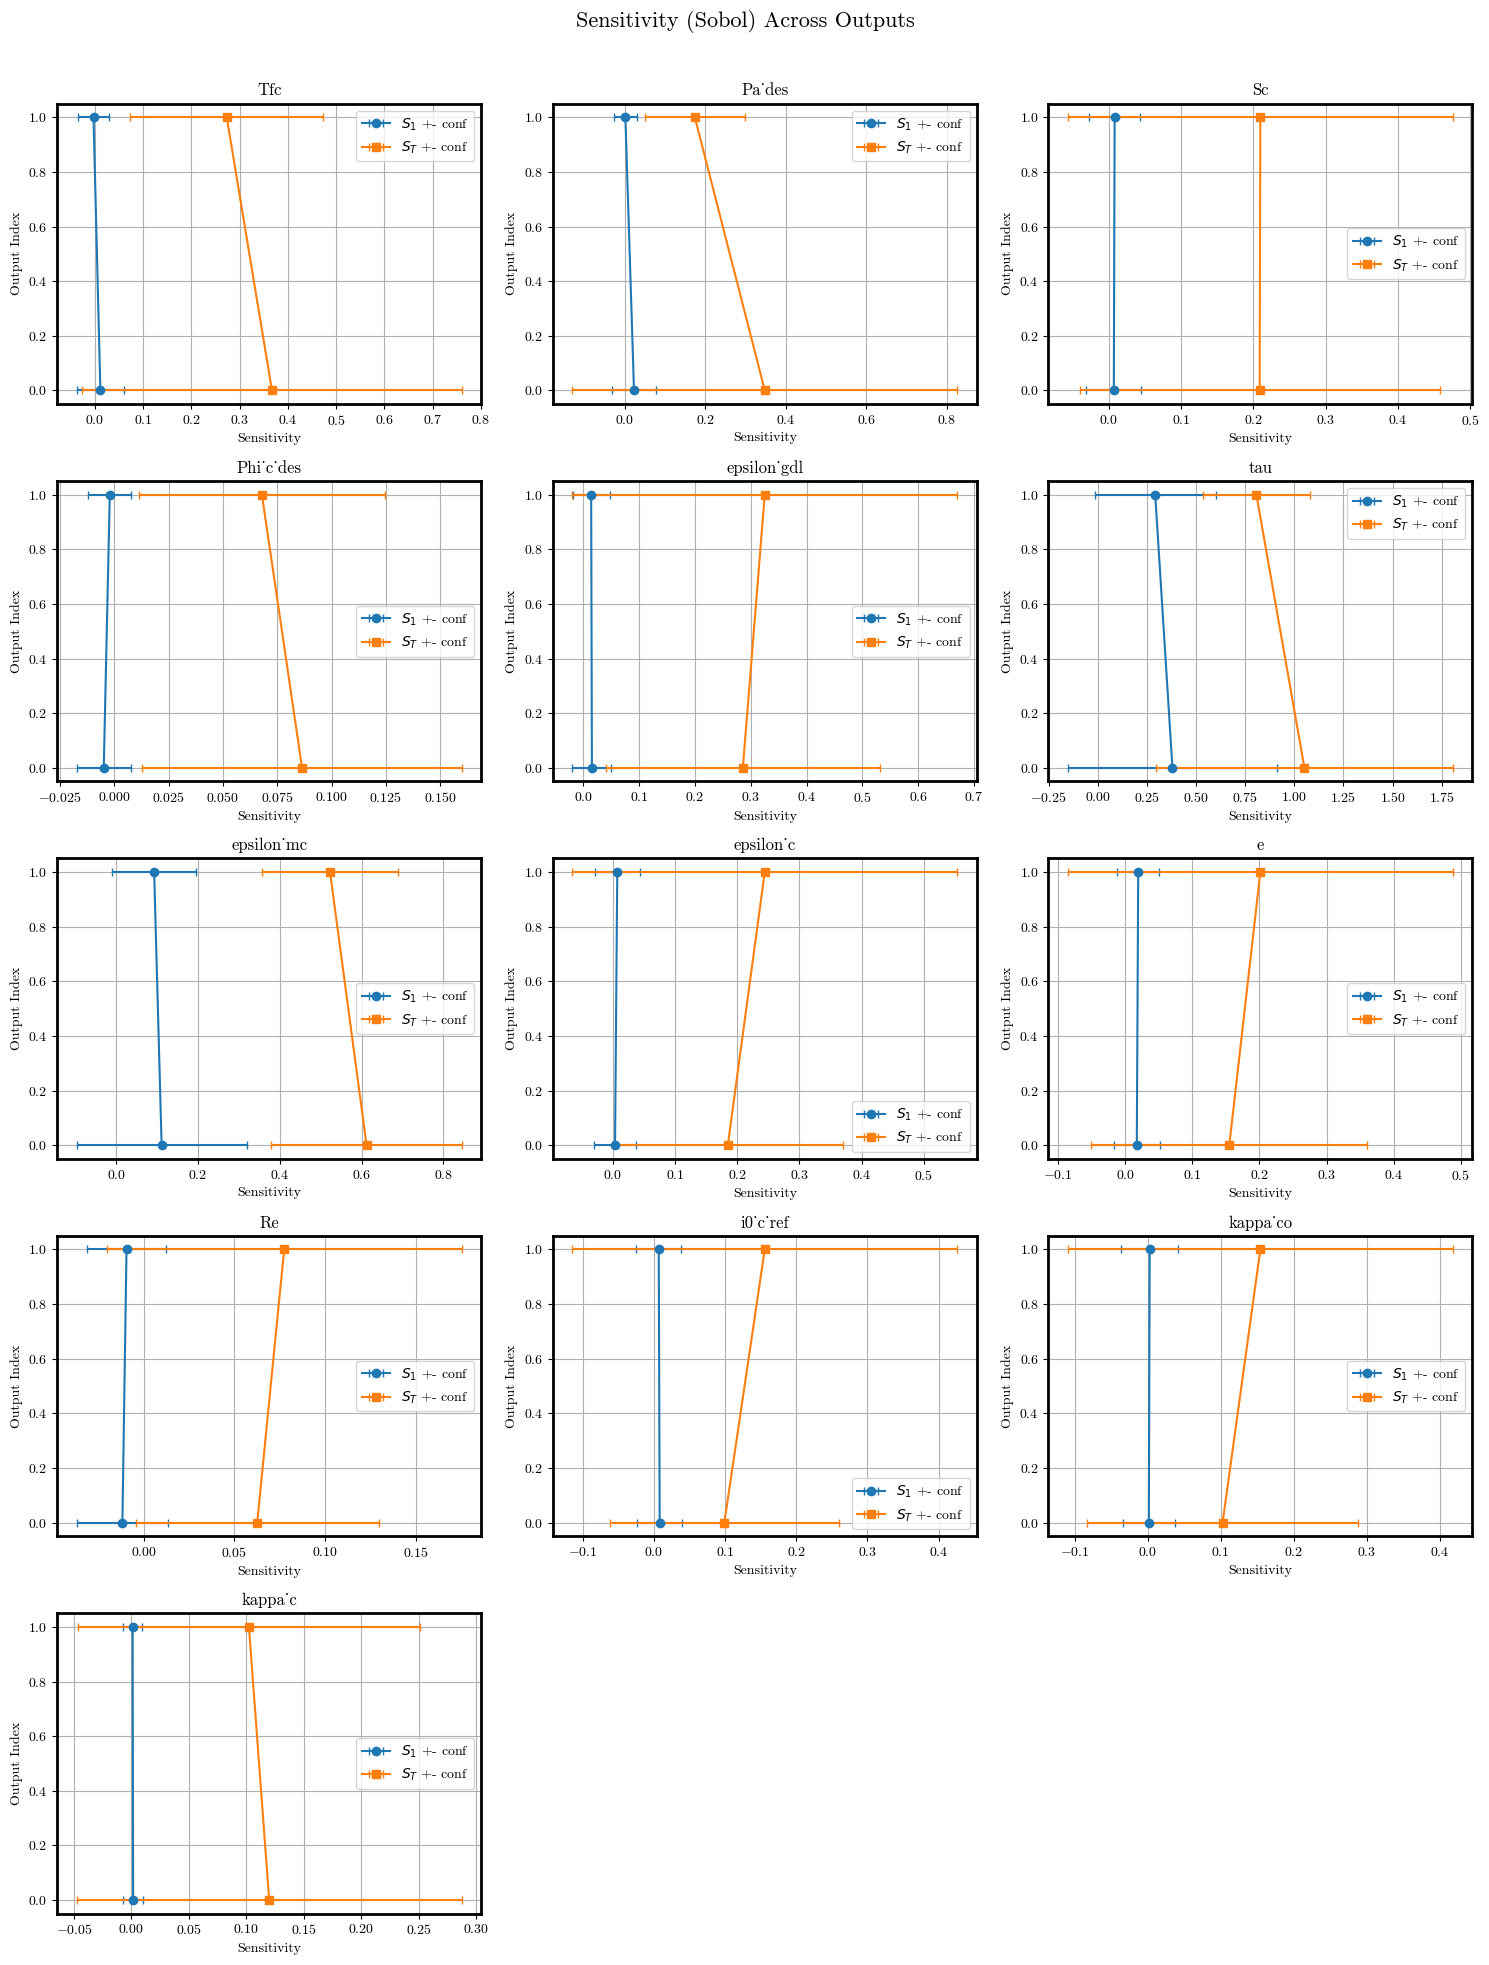

In [134]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=1024 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(data[cols][:len(samples)], "AUC", by_regions=True)
SA.plot_grid(results, same_axis=False)

/Users/dejvis.toptani/Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells/.venv/lib/python3.11/site-packages/SALib/util/__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


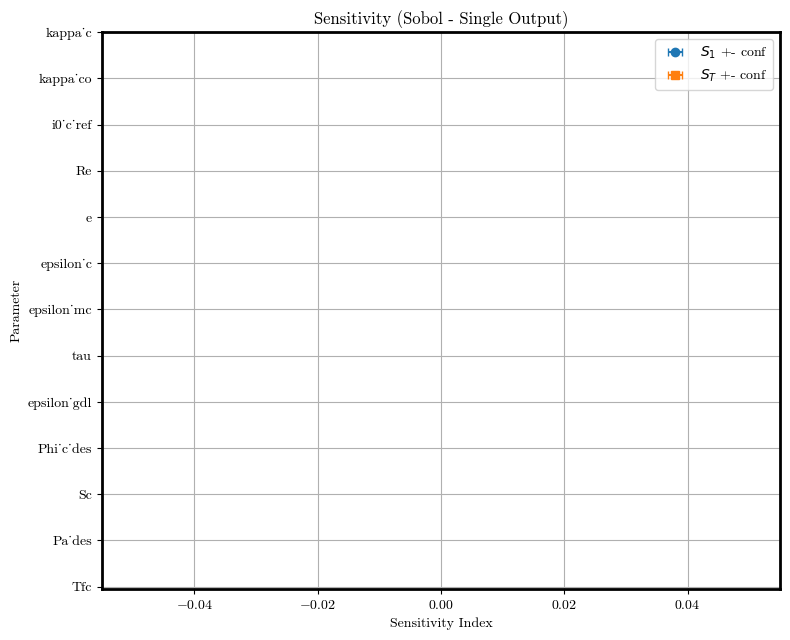

In [138]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=1024 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(data[cols][:len(samples)], "sum", by_regions=False)
SA.plot_grid(results, same_axis=False)

In [48]:
results[0]['ST'].sum()

np.float64(nan)

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method):
    rankings = []
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=True
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method=aggregation_method)

        # grab ST for output_index 0
        st = next(r['ST'] for r in results if r['output_index'] == 0)
        if param_names is None:
            param_names = results[0]['param']

        order = np.argsort(-st)     # descending
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(st)+1)
        rankings.append(dict(zip(param_names, ranks)))

    return pd.DataFrame(rankings, index=Ns)

import warnings
# 1) silence that specific FutureWarning
warnings.filterwarnings(
    "ignore",
    message="unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated"
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The balance properties of Sobol' points require n to be a power of 2"
)

# 1) build the full N list
Ns = list(range(2, 513, 4))   # [2, 6, 10, …, 254]

# 2) compute rank_df however you have it
rank_df = compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method="sum")



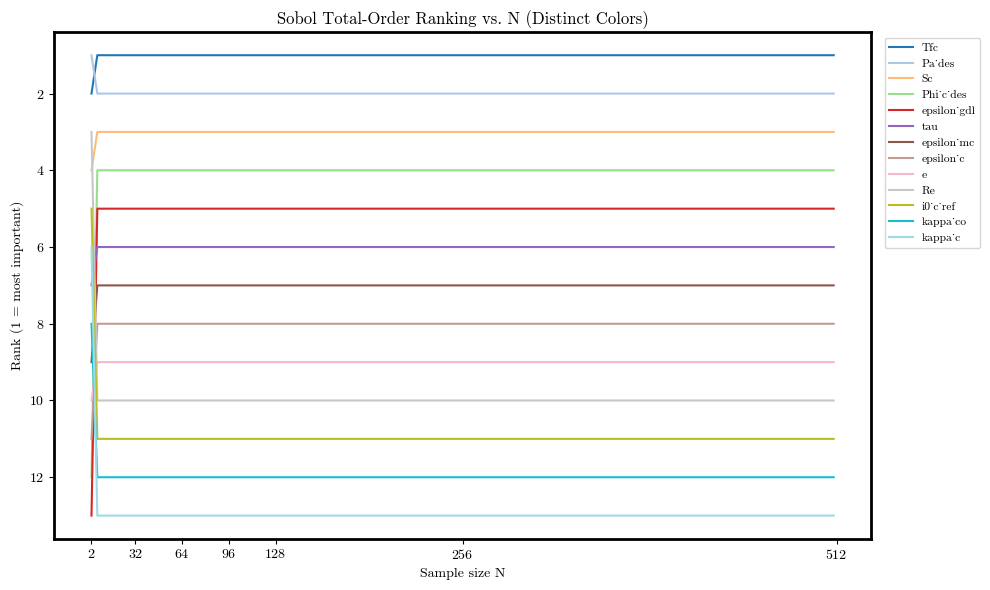

In [51]:
n_params = len(rank_df.columns)
cmap = plt.get_cmap('tab20', n_params)

plt.figure(figsize=(10, 6))
for idx, param in enumerate(rank_df.columns):
    y = rank_df[param].loc[Ns]
    plt.plot(Ns, y, color=cmap(idx), label=param)  # <-- label added

plt.gca().invert_yaxis()
plt.xticks([2, 32, 64, 96, 128, 256, 512])
plt.xlabel("Sample size N")
plt.ylabel("Rank (1 = most important)")
plt.title("Sobol Total-Order Ranking vs. N (Distinct Colors)")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)
plt.tight_layout()
plt.show()


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_indices_for_Ns(parameter_ranges, data, Ns, aggregation_method):
    """
    For each sample size N in Ns, run Sobol+fPCA analysis,
    extract total-order indices ST for the first output,
    and return a DataFrame of ST values (shape len(Ns) × n_params).
    """
    indices_list = []
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=True
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method=aggregation_method)

        # extract S_T for output_index == 0
        st = next(r['ST'] for r in results if r['output_index'] == 0)
        if param_names is None:
            param_names = results[0]['param']

        indices_list.append(dict(zip(param_names, st)))

    return pd.DataFrame(indices_list, index=Ns)

# 1) define N sweep
Ns = list(range(2, 513, 4))  # [2, 3, …, 128]
# 2) collect ST values
st_df = compute_indices_for_Ns(parameter_ranges, data, Ns, aggregation_method="sum")


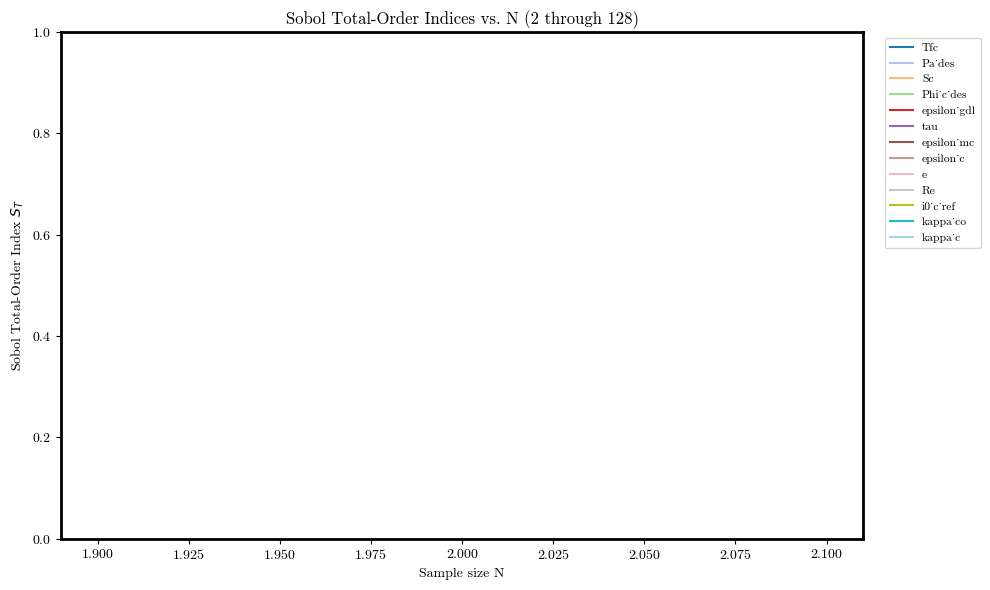

In [53]:

# 3) plot
cmap = plt.get_cmap('tab20', len(st_df.columns))

plt.figure(figsize=(10, 6))
for idx, param in enumerate(st_df.columns):
    plt.plot(
        st_df.index,
        st_df[param],
        label=param,
        color=cmap(idx)
    )

plt.xlabel("Sample size N")
plt.ylabel("Sobol Total-Order Index $S_T$")
plt.title("Sobol Total-Order Indices vs. N (2 through 128)")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize="small")
plt.tight_layout()
plt.show()

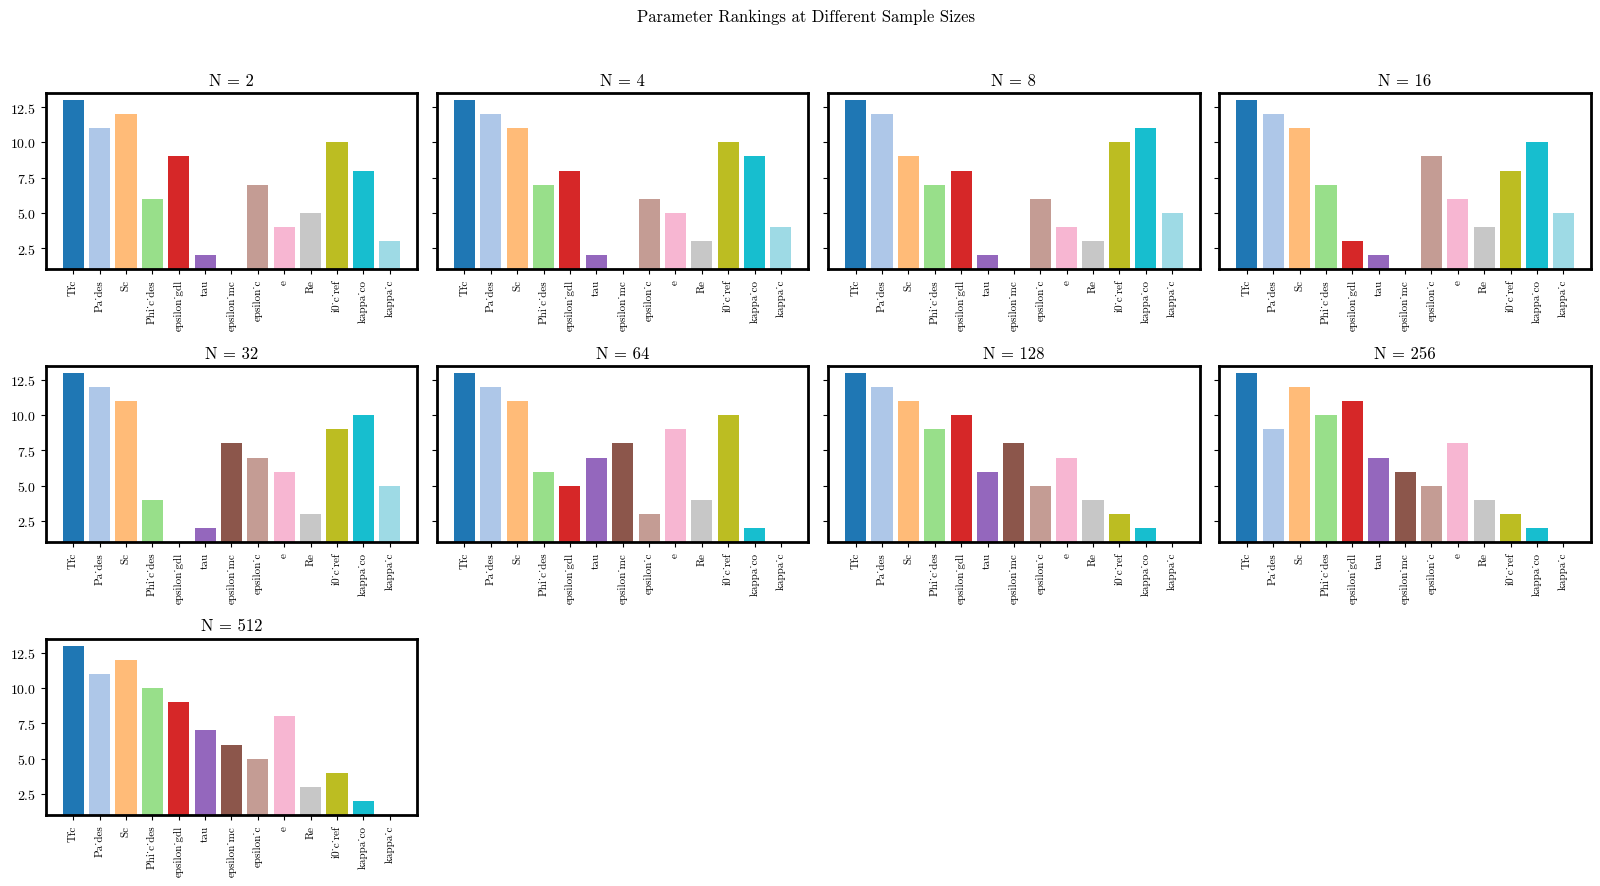

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose rank_df is your DataFrame of shape (len(Ns) × n_params), indexed by Ns
Ns = [2**i for i in range(1, 10)]         # [2, 4, 8, …, 256]

# 2) compute rank_df however you have it
rank_df = compute_rankings_for_Ns(parameter_ranges, data, Ns, aggregation_method="fPCA")
params = rank_df.columns.tolist()
n_params = len(params)

# Decide grid dimensions: e.g. 2 rows × 4 cols for eight plots
n_cols = 4
n_rows = int(np.ceil(len(Ns) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharey=True  # keep y-axis scale consistent
)

for ax, N in zip(axes.flat, Ns):
    # Get the ranking vector for this N
    ranks = rank_df.loc[N]

    # Draw a bar plot: x = parameter index, height = rank
    ax.bar(
        np.arange(n_params),
        ranks,
        color=plt.get_cmap('tab20', n_params).colors  # one distinct color per bar
    )
    ax.set_title(f"N = {N}")
    ax.set_xticks(np.arange(n_params))
    ax.set_xticklabels(params, rotation=90, fontsize=8)
    ax.invert_yaxis()             # rank 1 at top
    ax.set_ylim(1, n_params + 0.5)

# Turn off any unused subplots
for idx in range(len(Ns), n_rows * n_cols):
    fig.delaxes(axes.flat[idx])

fig.suptitle("Parameter Rankings at Different Sample Sizes")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Font 'default' does not have a glyph for '\u2010' [U+2010], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2010' [U+2010], substituting with a dummy symbol.


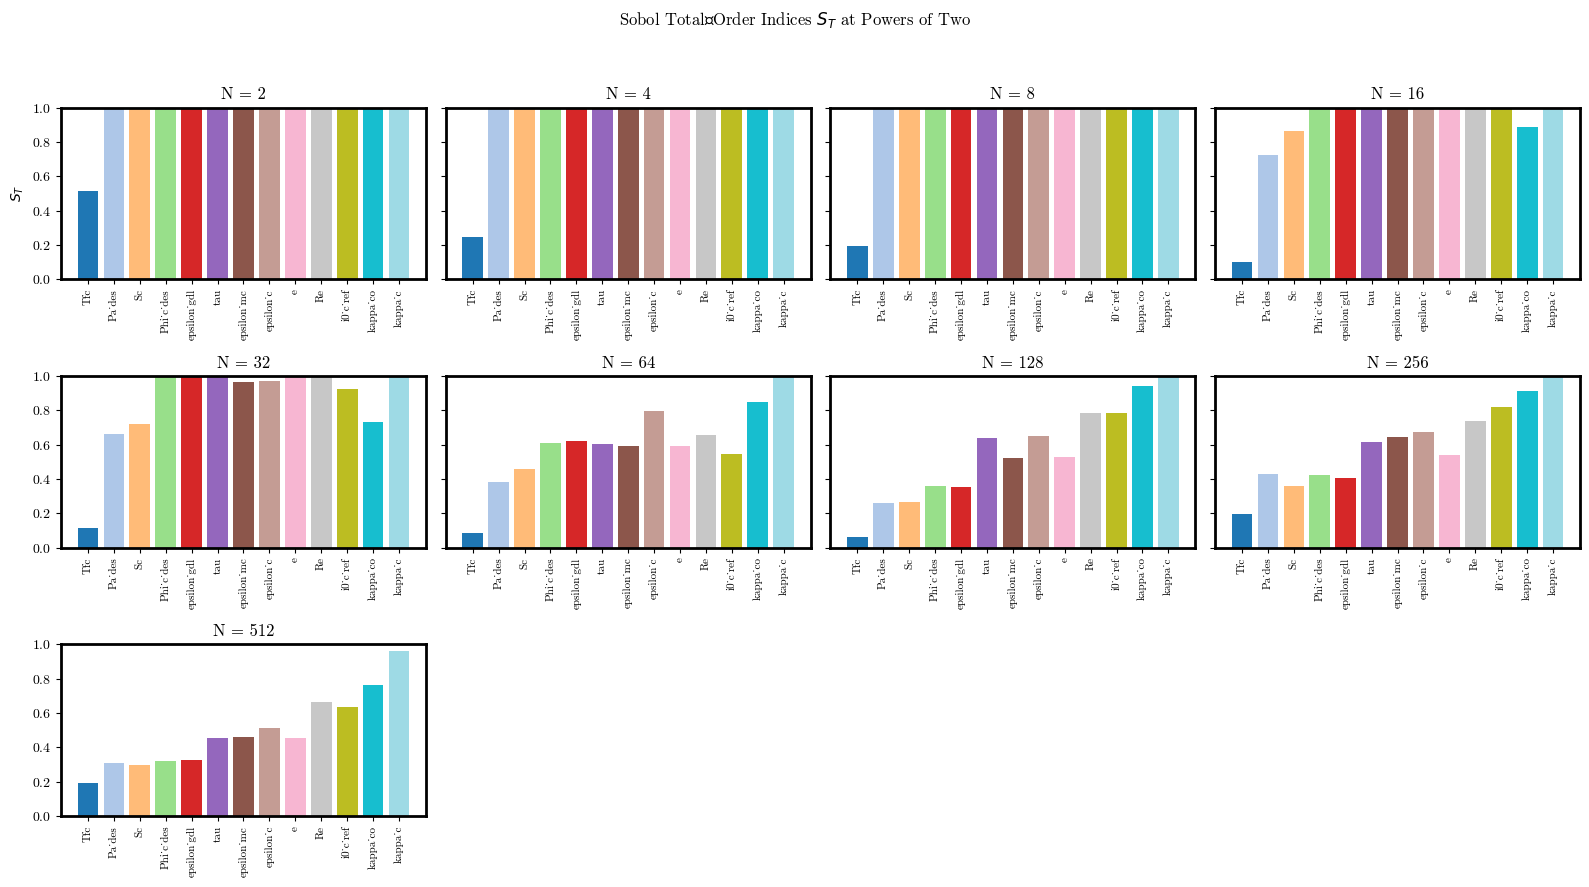

In [53]:
import numpy as np
import matplotlib.pyplot as plt

# 1) powers‐of‐two Ns
Ns = [2**i for i in range(1, 10)]   # [2, 4, 8, 16, 32, 64, 128, 256]
# 2) collect ST values
st_df = compute_indices_for_Ns(parameter_ranges, data, Ns, aggregation_method="fPCA")


params = st_df.columns.tolist()
n_params = len(params)

# 3) grid setup: 2 rows × 4 cols
n_cols = 4
n_rows = int(np.ceil(len(Ns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharey=True)

# 4) bar‐plot each N’s indices
colors = plt.get_cmap('tab20', n_params).colors
for ax, N in zip(axes.flat, Ns):
    indices = st_df.reindex(Ns).loc[N]  # ensure alignment

    ax.bar(
        np.arange(n_params),
        indices,
        color=colors
    )
    ax.set_title(f"N = {N}")
    ax.set_xticks(np.arange(n_params))
    ax.set_xticklabels(params, rotation=90, fontsize=8)
    ax.set_ylim(0, 1)               # Sobol indices in [0,1]
    ax.set_ylabel("$S_T$" if ax is axes.flat[0] else "")

# 5) clean up any empty subplots
for idx in range(len(Ns), n_rows * n_cols):
    fig.delaxes(axes.flat[idx])

fig.suptitle("Sobol Total‐Order Indices $S_T$ at Powers of Two")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


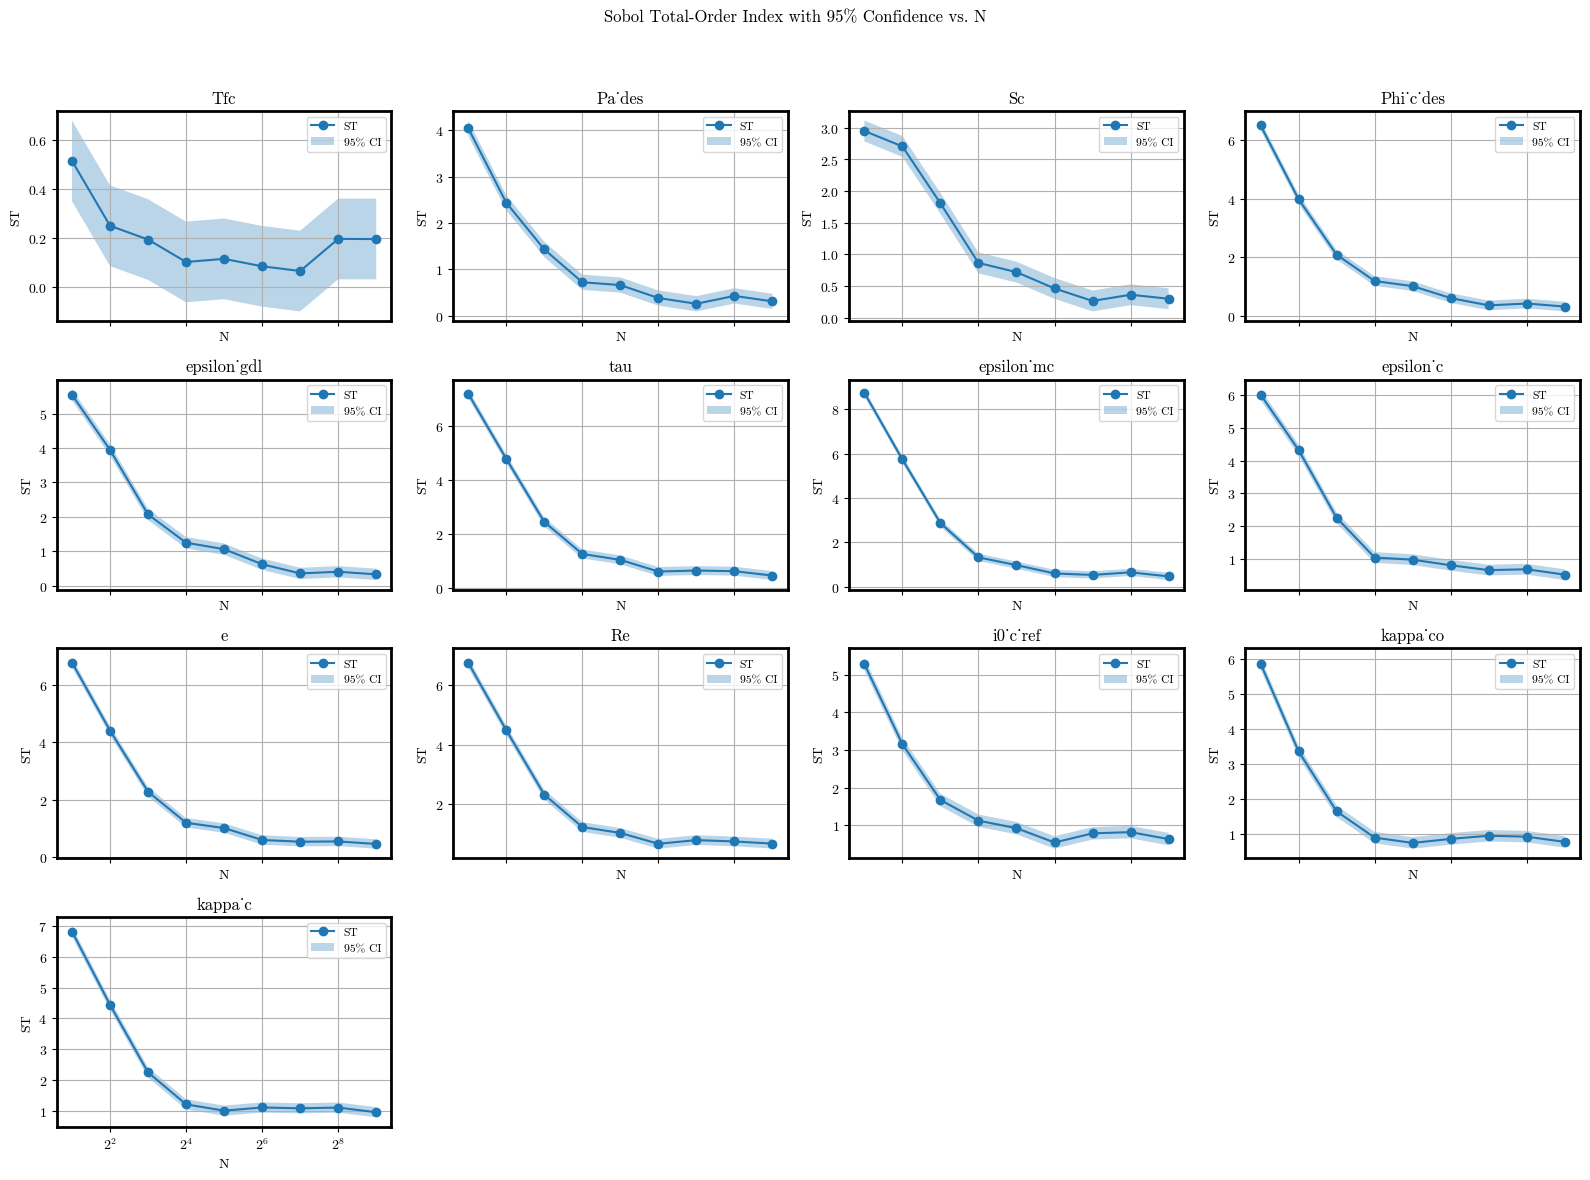

In [54]:
import numpy as np
import matplotlib.pyplot as plt

def plot_index_with_confidence(parameter_ranges, data, Ns, **SA_kwargs):
    """
    For each Sobol parameter, plot its total-order index and confidence interval vs N.
    
    parameter_ranges: dict of ranges passed to SensitivityAnalyzer
    data: DataFrame containing 'Ucell' and 'ifc' columns
    Ns: list of sample sizes (powers of two)
    SA_kwargs: other kwargs for SensitivityAnalyzer (method, seed, calculate_second_order)
    """
    # Storage for each parameter: dict mapping param -> list of (N, ST, ST_conf)
    ci_data = {}
    # Run for each N
    for N in Ns:
        SA = SensitivityAnalyzer(parameter_ranges, method='sobol', seed=42, N=N, calculate_second_order=True)
        samples = SA.generate_samples()
        cols = list(samples.columns) + ['Ucell', 'ifc']
        results = SA.run_analysis(data[cols].iloc[:len(samples)], aggregation_method="fPCA")
        # Extract ST and ST_conf for output 0
        for res in results:
            if res['output_index'] == 0:
                for param, st, conf in zip(res['param'], res['ST'], res['ST_conf']):
                    ci_data.setdefault(param, []).append((N, st, conf))
                break

    # Now plot one subplot per parameter
    n_params = len(ci_data)
    cols = 4
    rows = int(np.ceil(n_params / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharex=True, sharey=False)
    
    for ax, (param, vals) in zip(axes.flat, ci_data.items()):
        vals_sorted = sorted(vals, key=lambda x: x[0])
        Ns_plot, sts, confs = zip(*vals_sorted)
        sts = np.array(sts)
        confs = np.array(confs)
        ax.plot(Ns_plot, sts, marker='o', label='ST')
        ax.fill_between(Ns_plot, sts-conf, sts+conf, alpha=0.3, label='95% CI')
        ax.set_xscale('log', base=2)
        ax.set_title(param)
        ax.set_xlabel("N")
        ax.set_ylabel("ST")
        ax.grid(True)
        ax.legend(loc='upper right', fontsize='small')
    
    # Remove any extra axes
    for idx in range(n_params, rows*cols):
        fig.delaxes(axes.flat[idx])

    fig.suptitle("Sobol Total-Order Index with 95% Confidence vs. N")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Example usage:
Ns = [2,4,8,16,32,64,128, 256, 512]
plot_index_with_confidence(parameter_ranges, data, Ns)


C:\Users\dejvi\AppData\Local\Temp\ipykernel_17996\4046259457.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.95])


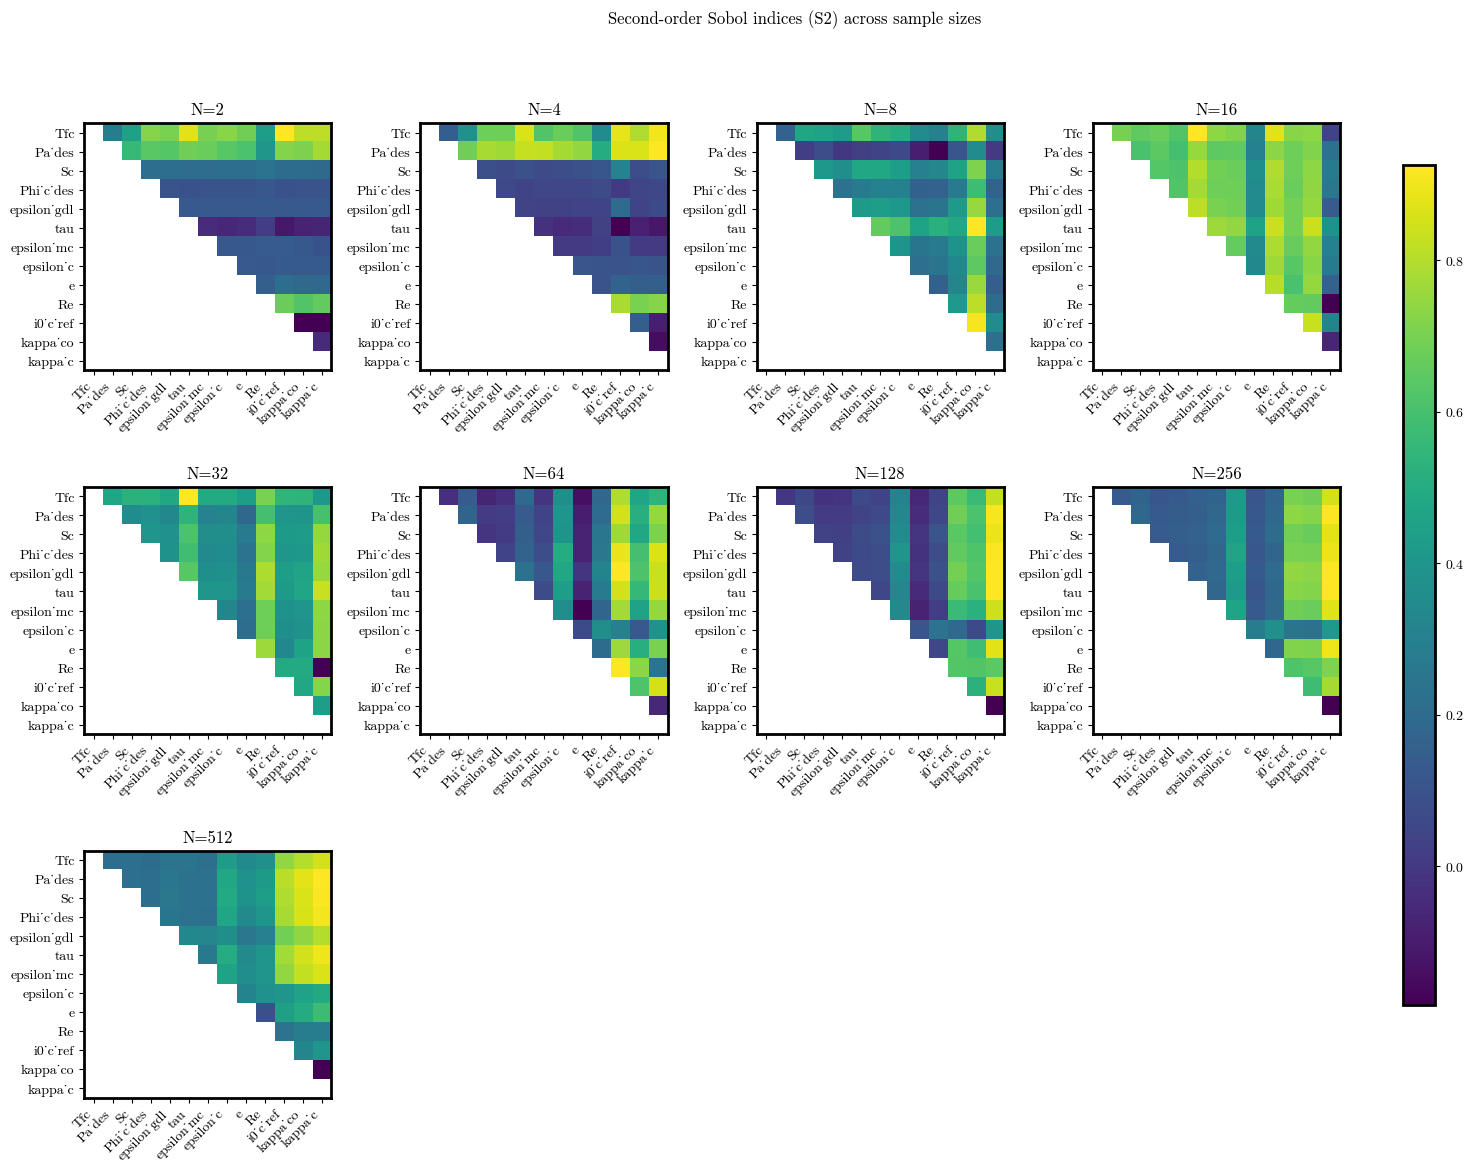

In [16]:
import numpy as np
import matplotlib.pyplot as plt

def plot_all_sobol_s2(results, param_names=None, ncols=4, figsize_per_plot=(4, 4), cmap='viridis'):
    """
    Plot all second-order Sobol indices (S2) heatmaps from a list of Sobol results in a grid layout.

    Parameters:
        results (list of dict): each dict contains keys 'param', 'S2', and should include 'N' for sample size.
        param_names (list of str, optional): common parameter names. If None, uses each entry's 'param'.
        ncols (int): number of columns in the grid.
        figsize_per_plot (tuple): width and height for each subplot in inches.
        cmap (str): matplotlib colormap name.

    Raises:
        ValueError: if any entry lacks 'S2' data.
    """
    nplots = len(results)
    if nplots == 0:
        raise ValueError("No results to plot.")

    # Determine grid size
    nrows = int(np.ceil(nplots / ncols))
    fig_width = figsize_per_plot[0] * ncols
    fig_height = figsize_per_plot[1] * nrows
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_width, fig_height), squeeze=False)

    for idx, entry in enumerate(results):
        row = idx // ncols
        col = idx % ncols
        ax = axes[row][col]

        # Extract and validate S2 matrix
        S2 = np.array(entry.get('S2', []))
        if S2.size == 0:
            raise ValueError(f"Entry at index {idx} has no 'S2'")

        # Determine parameter names
        names = param_names or entry.get('param')
        if names is None:
            n = S2.shape[0]
            names = [f'x{i}' for i in range(n)]

        # Reshape if needed
        n = len(names)
        if S2.shape != (n, n):
            try:
                S2 = S2.reshape((n, n))
            except Exception:
                raise ValueError(f"Cannot reshape S2 of shape {S2.shape} into ({n},{n})")

        # Plot heatmap on subplot
        cax = ax.imshow(S2, interpolation='nearest', cmap=cmap)
        ax.set_xticks(np.arange(n))
        ax.set_yticks(np.arange(n))
        ax.set_xticklabels(names, rotation=45, ha='right')
        ax.set_yticklabels(names)

        # Title using sample size N
        if 'N' in entry:
            ax.set_title(f"N={entry['N']}")
        else:
            ax.set_title(f"Run {idx}")

    # Hide unused subplots
    for idx in range(nplots, nrows * ncols):
        row = idx // ncols
        col = idx % ncols
        axes[row][col].axis('off')

    # Add colorbar
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    fig.colorbar(cax, cax=cbar_ax)
    fig.suptitle('Second-order Sobol indices (S2) across sample sizes')
    plt.tight_layout(rect=[0, 0, 0.85, 0.95])
    plt.show()


results = []
Ns = [2,4,8,16,32,64,128, 256, 512]
for N in Ns:
    SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=N , calculate_second_order=True)
    samples = SA.generate_samples()
    cols = list(samples.columns)
    cols.append('Ucell')
    cols.append('ifc')
    results.append(SA.run_analysis(data[cols][:len(samples)], "fPCA")[0])

# Ensure each result dict includes 'N' key before plotting:
for i, N in enumerate(Ns):
     results[i]['N'] = N
# Example usage:
plot_all_sobol_s2(results)


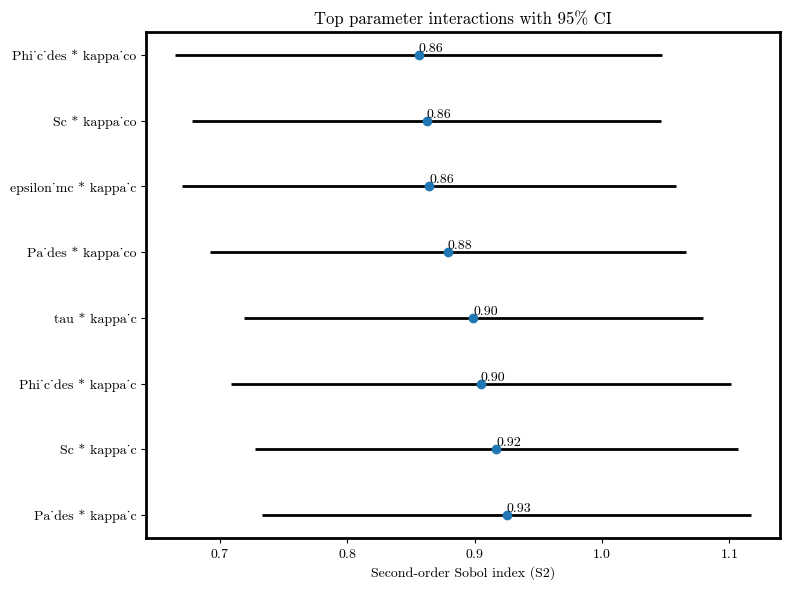

In [17]:
import itertools
def plot_forest_interactions(results, param_names=None, top_k=10, include_ci=True, sort_desc=True, figsize=(8, 6), fmt=".2f", line_kwargs=None, marker_kwargs=None, text_kwargs=None):
    '''
    Plot a forest-style plot of top-k parameter interactions with confidence intervals.

    Each interaction is shown on the y-axis, with a horizontal line for the confidence interval
    and a central marker for the mean S2 value.

    Parameters:
        results (list of dict): one Sobol result dict (or list where only the first is used).
        param_names (list of str, optional): parameter names. If None, uses result['param'].
        top_k (int): number of top interactions to display.
        include_ci (bool): whether to plot confidence intervals from 'S2_conf'.
        sort_desc (bool): sort interactions by descending S2.
        figsize (tuple): figure size (width, height).
        fmt (str): format string for annotating mean values.
        line_kwargs (dict, optional): kwargs for hlines (e.g., linewidth).
        marker_kwargs (dict, optional): kwargs for plot markers (e.g., marker style).
        text_kwargs (dict, optional): kwargs for annotation text (fontsize, va, etc.).

    Raises:
        ValueError: if S2 data is missing.
    '''
    entry = results[0] if isinstance(results, list) else results
    S2 = np.array(entry.get('S2', []))
    ci = np.array(entry.get('S2_conf', [])) if include_ci else None
    if S2.size == 0:
        raise ValueError('No S2 data found.')

    names = param_names or entry.get('param')
    if names is None:
        n = S2.shape[0]
        names = [f'x{i}' for i in range(n)]

    n = len(names)
    pairs = list(itertools.combinations(range(n), 2))
    vals = [S2[i, j] for i, j in pairs]
    errs = [ci[i, j] if include_ci else 0 for i, j in pairs]

    interactions = [((names[i], names[j]), v, e) for (i, j), v, e in zip(pairs, vals, errs)]
    interactions.sort(key=lambda x: x[1], reverse=sort_desc)
    top = interactions[:top_k]

    labels = [f'{a} * {b}' for (a, b), _, _ in top]
    means = [v for _, v, _ in top]
    cis = [e for _, _, e in top]

    # Reverse for plotting top at top
    labels = labels[::-1]
    means = means[::-1]
    cis = cis[::-1]
    y_pos = np.arange(len(labels))

    if line_kwargs is None:
        line_kwargs = {'linewidth': 2}
    if marker_kwargs is None:
        marker_kwargs = {'marker': 'o', 'linestyle': ''}
    if text_kwargs is None:
        text_kwargs = {'fontsize': 10, 'va': 'bottom'}

    fig, ax = plt.subplots(figsize=figsize)
    # Plot CIs as horizontal lines
    if include_ci:
        for y, mean, ci_val in zip(y_pos, means, cis):
            ax.hlines(y, mean - ci_val, mean + ci_val, color='black', **line_kwargs)
    # Plot mean markers
    ax.plot(means, y_pos, **marker_kwargs)

    # Annotate mean values above markers
    for x, y in zip(means, y_pos):
        ax.text(x, y, format(x, fmt), **text_kwargs)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Second-order Sobol index (S2)')
    ax.set_title('Top parameter interactions with 95% CI')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
plot_forest_interactions(results[-1], top_k=8)

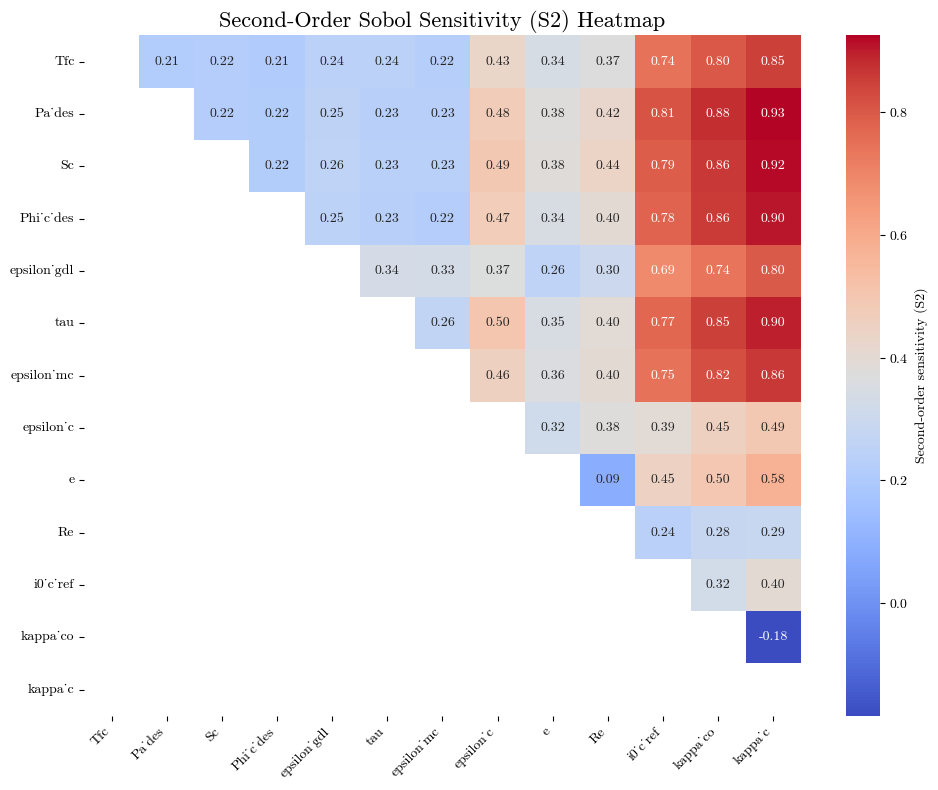

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns  # For nicer heatmaps

def plot_sobol_S2_heatmap(sobol_result):
    """
    Plots the S2 (second-order Sobol indices) as a heatmap.
    
    Parameters:
        sobol_result (dict): Single output's Sobol sensitivity analysis result.
        problem (dict): Dictionary containing problem information, including parameter names.
    """
    param_names = sobol_result['param']
    n_params = len(param_names)
    
    # Extract S2 matrix
    S2_matrix = np.zeros((n_params, n_params))

    for i in range(n_params):
        for j in range(n_params):
            if i == j:
                S2_matrix[i, j] = np.nan  # You can decide to put NaN or 0 on the diagonal (no self-interaction)
            else:
                S2_matrix[i, j] = sobol_result['S2'][i][j]

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(S2_matrix, 
                xticklabels=param_names, 
                yticklabels=param_names, 
                cmap="coolwarm", 
                annot=True, 
                fmt=".2f", 
                mask=np.isnan(S2_matrix),
                cbar_kws={'label': 'Second-order sensitivity (S2)'})
    
    plt.title('Second-Order Sobol Sensitivity (S2) Heatmap', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_sobol_S2_heatmap(results[-1])

In [73]:
import pandas as pd
import numpy as np
# Load data
data = all.copy()
cols = list(data.columns[:13])
cols.append('Ucell')
data = data[cols]
data = data.dropna()

# Step 1: Stack Ucell values into a 2D array
ucell_array = np.stack(data['Ucell'].to_numpy())

# Step 2: Create new column names for the Ucell components
ucell_cols = [f'Ucell_{i}' for i in range(ucell_array.shape[1])]

# Step 3: Create a DataFrame from the stacked array
ucell_df = pd.DataFrame(ucell_array, columns=ucell_cols, index=data.index)

# Step 4: Drop the original 'Ucell' column and concatenate the expanded columns
data_wide = pd.concat([data.drop(columns='Ucell'), ucell_df], axis=1)
data_wide

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,...,Ucell_21,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.739037,0.729581,0.720127,0.710685,0.701266,0.691858,0.682437,0.672987,0.663492,0.653933
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.721292,0.714529,0.707308,0.699520,0.691411,0.682963,0.674201,0.665215,0.656067,0.646718
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.671943,0.674925,0.678619,0.672719,0.664526,0.658328,0.651771,0.644673,0.636798,0.628506
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.726456,0.716600,0.706744,0.696881,0.686989,0.677044,0.667028,0.656922,0.646707,0.636362
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,...,0.738844,0.729362,0.719902,0.710475,0.701074,0.691673,0.682255,0.672806,0.663305,0.653740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28667,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000005,...,0.639510,0.625377,0.611309,0.597290,0.583306,0.569347,0.555400,0.541456,0.527501,0.513527
28668,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,...,0.634814,0.623167,0.611584,0.600051,0.588553,0.577079,0.565618,0.554158,0.542689,0.531200
28669,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,...,0.689641,0.678033,0.666486,0.654984,0.643514,0.632065,0.620625,0.609184,0.597730,0.586254
28670,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,...,0.684767,0.674628,0.664588,0.654633,0.644750,0.634929,0.625162,0.615438,0.605748,0.596083


In [51]:
from SALib.analyze import hdmr
import numpy as np
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=512 , calculate_second_order=True)

unscaled = SA.generate_samples()
rescaled = SA.rescale_samples()
samples = SA.apply_dependent_parameters(dependent_parameters)

# Suppose parameter_ranges.keys() is an ordered list of your D variable names:
var_names = list(parameter_ranges.keys())

# 1) Grab the first N rows (matching your sample size) as a DataFrame...
X_df = data[var_names].iloc[: len(samples) ]

# 2) ...and convert to a NumPy array:
X = X_df.to_numpy()            # shape (N, D)

# 3) Likewise for Y:
Y = SA.aggregate_output_function(data, aggregation_method="fPCA")[: len(samples) ]  # shape (N,)

Si = hdmr.analyze(
    problem=SA.problem,
    X=X,
    Y=Y,
    maxorder=2,
    seed= 42,
    print_to_console=True
)

/var/folders/nh/g7l50kcx5r9g8d05q_6qbr000000gn/T/ipykernel_73799/3105393205.py:21: DeprecationWarning: This method will be retired in future, please use enhanced_hdmr instead.
  Si = hdmr.analyze(




Term    	      Sa            Sb             S             ST         #select 
------------------------------------------------------------------------------------
Tfc           	  0.15 (±0.00) -0.00 (±0.01)  0.15 (±0.01)  0.17 (±0.01)    1  
Pa_des        	  0.16 (±0.01) -0.00 (±0.00)  0.16 (±0.01)  0.20 (±0.01)    1  
Sc            	  0.01 (±0.00) -0.00 (±0.00)  0.00 (±0.00)  0.02 (±0.00)    1  
Phi_c_des     	  0.01 (±0.00)  0.00 (±0.00)  0.01 (±0.00)  0.02 (±0.00)    1  
epsilon_gdl   	  0.00 (±0.00)  0.00 (±0.00)  0.00 (±0.00)  0.01 (±0.00)    1  
tau           	  0.04 (±0.00) -0.00 (±0.00)  0.04 (±0.00)  0.06 (±0.00)    1  
epsilon_mc    	  0.03 (±0.00)  0.00 (±0.00)  0.03 (±0.00)  0.05 (±0.01)    1  
epsilon_c     	  0.00 (±0.00)  0.00 (±0.00)  0.00 (±0.00)  0.01 (±0.00)    1  
e             	  0.00 (±0.00) -0.00 (±0.00) -0.00 (±0.00)  0.00 (±0.00)    1  
Re            	  0.06 (±0.00)  0.00 (±0.00)  0.06 (±0.00)  0.07 (±0.01)    1  
i0_c_ref      	  0.38 (±0.01)  0.01 (±0.01)  

In [48]:
import numpy as np

# Si is the dict you got back from hdmr.analyze
Sa = np.array(Si["Sa"])
Sb = np.array(Si["Sb"])
S  = np.array(Si["S"])
ST = np.array(Si["ST"])

print(f"Σ Sa  = {Sa.sum():.3f}   (should be ≤ 1, ~1 if additive)")
print(f"Σ Sb  = {Sb.sum():.3f}   (captures correlated variance)")
print(f"Σ S   = {S.sum():.3f}   (total term contributions; may exceed 1 if interactions overlap)")
print(f"Σ ST  = {np.nansum(ST):.3f}  (total-order; typically ≥1 when interactions present)")


Σ Sa  = 1.042   (should be ≤ 1, ~1 if additive)
Σ Sb  = 0.169   (captures correlated variance)
Σ S   = 1.050   (total term contributions; may exceed 1 if interactions overlap)
Σ ST  = 1.166  (total-order; typically ≥1 when interactions present)


In [52]:
import numpy as np

# Suppose Si is the dict returned by hdmr.analyze(...)
terms = Si["Term"]
S_vals = np.array(Si["S"], dtype=float)

# 1) First‐order (main‐effect) Sobol indices S1
S1 = {t: S_vals[i] for i, t in enumerate(terms) if "/" not in t}
print("First-order S1 indices:")
for name, val in S1.items():
    print(f"  {name}: {val:.3f}")

# 2) Second‐order (pairwise) Sobol indices S2
S2 = {t: S_vals[i] for i, t in enumerate(terms) if "/" in t}
print("\nSecond-order S2 indices:")
for name, val in S2.items():
    print(f"  {name}: {val:.3f}")

# 3) (Optional) Total‐order ST—if you ran with second-order enabled
#    just ignore NaNs as before:
ST_vals = np.array(Si["ST"], dtype=float)
valid = ~np.isnan(ST_vals)
ST = {terms[i]: ST_vals[i] for i in np.where(valid)[0]}
print("\nTotal-order ST indices:")
for name, val in ST.items():
    print(f"  {name}: {val:.3f}")


First-order S1 indices:
  Tfc: 0.150
  Pa_des: 0.161
  Sc: 0.005
  Phi_c_des: 0.008
  epsilon_gdl: 0.001
  tau: 0.042
  epsilon_mc: 0.032
  epsilon_c: 0.001
  e: -0.000
  Re: 0.057
  i0_c_ref: 0.382
  kappa_co: 0.004
  kappa_c: 0.092

Second-order S2 indices:
  Tfc/Pa_des: 0.006
  Tfc/Sc: 0.001
  Tfc/Phi_c_des: 0.004
  Tfc/epsilon_gdl: 0.000
  Tfc/tau: 0.002
  Tfc/epsilon_mc: 0.002
  Tfc/epsilon_c: 0.001
  Tfc/e: 0.000
  Tfc/Re: 0.000
  Tfc/i0_c_ref: 0.001
  Tfc/kappa_co: 0.001
  Tfc/kappa_c: 0.001
  Pa_des/Sc: 0.001
  Pa_des/Phi_c_des: 0.002
  Pa_des/epsilon_gdl: 0.001
  Pa_des/tau: 0.001
  Pa_des/epsilon_mc: 0.002
  Pa_des/epsilon_c: 0.000
  Pa_des/e: 0.000
  Pa_des/Re: 0.000
  Pa_des/i0_c_ref: 0.003
  Pa_des/kappa_co: 0.001
  Pa_des/kappa_c: 0.023
  Sc/Phi_c_des: 0.001
  Sc/epsilon_gdl: 0.001
  Sc/tau: 0.002
  Sc/epsilon_mc: 0.001
  Sc/epsilon_c: 0.000
  Sc/e: 0.000
  Sc/Re: 0.001
  Sc/i0_c_ref: 0.001
  Sc/kappa_co: -0.000
  Sc/kappa_c: 0.004
  Phi_c_des/epsilon_gdl: 0.000
  Phi_c_d

In [61]:
# Suppose you ran:
# Si = hdmr.analyze(...)

import numpy as np

terms = Si["Term"]
S_vals = np.array(Si["S"], dtype=float)

# Extract S1 and S2
S1 = {t: S_vals[i] for i, t in enumerate(terms) if "/" not in t}
S2 = {t: S_vals[i] for i, t in enumerate(terms) if "/" in t}

sum_S1 = sum(S1.values())
sum_S2 = sum(S2.values())
total = sum_S1 + sum_S2
residual = 1.0 - total

print(f"Sum first-order (ΣS1)   = {sum_S1:.4f}")
print(f"Sum second-order (ΣS2)  = {sum_S2:.4f}")
print(f"ΣS1 + ΣS2                = {total:.4f}")
print(f"Residual (1 − ΣS1 − ΣS2) = {residual:.4f}")

if abs(residual) < 1e-2:
    print("✔︎ Indices are effectively additive (within Monte Carlo error).")
else:
    print("✘ Significant non‐additivity detected; consider more samples or higher maxorder.")


Sum first-order (ΣS1)   = 0.9345
Sum second-order (ΣS2)  = 0.1158
ΣS1 + ΣS2                = 1.0504
Residual (1 − ΣS1 − ΣS2) = -0.0504
✘ Significant non‐additivity detected; consider more samples or higher maxorder.


In [62]:
from SALib.analyze import delta

Si = delta.analyze(SA.problem, X, Y, print_to_console=True)

                delta  delta_conf        S1   S1_conf
Tfc          0.183510    0.006594  0.162245  0.012255
Pa_des       0.171036    0.006985  0.164450  0.010832
Sc           0.082426    0.005387  0.018112  0.005744
Phi_c_des    0.092340    0.005732  0.014124  0.005023
epsilon_gdl  0.092842    0.006054  0.007938  0.003694
tau          0.113982    0.005947  0.048894  0.007198
epsilon_mc   0.106157    0.006248  0.034196  0.006816
epsilon_c    0.102545    0.007088  0.010203  0.004990
e            0.042776    0.002936  0.002002  0.001099
Re           0.106101    0.005583  0.053431  0.007066
i0_c_ref     0.255952    0.006777  0.396036  0.016372
kappa_co     0.106715    0.006904  0.030609  0.007937
kappa_c      0.144763    0.005872  0.110841  0.009583
